In [15]:
import pandas as pd
import numpy as np
import torch
import warnings
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib 
import matplotlib.pyplot as plt


In [16]:
# 1. Chargement
chemin = r"E:\PROJET\Linkden\base de donne\Base_IA_Prete_1.xlsx"
df = pd.read_excel(chemin)

warnings.filterwarnings("ignore", category=UserWarning)

 # 2. Gestion des dates (si présentes, on les transforme en colonnes numériques)
for col in df.columns:
    if df[col].dtype == 'object' or 'date' in col.lower():
        try:
            temp_date = pd.to_datetime(df[col])
            df[f'{col}_annee'] = temp_date.dt.year
            df[f'{col}_mois'] = temp_date.dt.month
            df = df.drop(columns=[col])
        except:
            pass

# 3. Force brute numérique : on transforme tout en chiffre
# Les erreurs deviennent des NaN, puis on les supprime
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()

# 4. Séparation X (facteurs) et y (résultat)
X = df.drop(columns=['Presence']).values
y = df['Presence'].values

# 5. Division 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Normalisation 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7. Tenseurs PyTorch
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).view(-1, 1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).view(-1, 1)

print(f"Base de données importée ! Lignes valides : {len(df)}")
print(f"Nombre de variables d'entrée : {X_train.shape[1]}")


Base de données importée ! Lignes valides : 4587
Nombre de variables d'entrée : 6


In [5]:
import pandas as pd
import numpy as np
from sklearn.utils import resample

chemin = r"E:\PROJET\Linkden\base de donne\Base_IA_Prete_1.xlsx"
df = pd.read_excel(chemin)
#  ÉTAPE 1 : DÉFINITION DES COLONNES (L'oubli du NameError) ---
colonnes_X = ['Exposition', 'Vegetation', 'rugosite', 'precipitation_annuelle', 'pente', 'Hypsometrie']

#  ÉTAPE 2 : NETTOYAGE 
# 1. Supprimer les doublons
df_clean = df.drop_duplicates()

# 2. Supprimer les lignes vides sur les facteurs ou la cible
df_clean = df_clean.dropna(subset=colonnes_X + ['Presence'])

# 3. Supprimer les valeurs "infinies" et remplacer par NaN pour les supprimer
df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna(subset=colonnes_X)

# 4. Conversion forcée en numérique (au cas où il y aurait des textes cachés)
for col in colonnes_X:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
df_clean = df_clean.dropna(subset=colonnes_X)

print(f"Après nettoyage strict : {len(df_clean)} lignes valides.")

Après nettoyage strict : 4587 lignes valides.


In [6]:
#  ÉTAPE 3 : ÉQUILIBRAGE 
df_non = df_clean[df_clean['Presence'] == 0]
df_oui = df_clean[df_clean['Presence'] == 1]

# On trouve la taille de la plus petite classe après nettoyage
n_samples = min(len(df_non), len(df_oui)) 

# On égalise
df_non_final = resample(df_non, replace=False, n_samples=n_samples, random_state=42)
df_oui_final = resample(df_oui, replace=False, n_samples=n_samples, random_state=42)

# Fusion
df_final = pd.concat([df_non_final, df_oui_final]).sample(frac=1).reset_index(drop=True)

print(f"--- RÉSULTAT FINAL ---")
print(f"Total lignes : {len(df_final)}")
print(f"Répartition : {n_samples} SANS / {n_samples} AVEC")

--- RÉSULTAT FINAL ---
Total lignes : 4428
Répartition : 2214 SANS / 2214 AVEC


In [7]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Sélection des facteurs et de la cible
X = df_final[colonnes_X].values
y = df_final['Presence'].values.reshape(-1, 1)

# 2. Division Train/Test (80% pour apprendre, 20% pour vérifier)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Normalisation (Crucial : on apprend sur le train, on applique au test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Conversion en Tenseurs PyTorch
X_t = torch.FloatTensor(X_train_scaled)
y_t = torch.FloatTensor(y_train)
X_val = torch.FloatTensor(X_test_scaled)
y_val = torch.FloatTensor(y_test)

print(f"Prêt pour l'entraînement : {X_t.shape[0]} échantillons d'apprentissage.")

Prêt pour l'entraînement : 3542 échantillons d'apprentissage.


In [8]:
# MIS EN PLACE DE STRUCTURE DE CERVEAUX
class CerveauGeologique(nn.Module):
    def __init__(self, n_entree):
        super(CerveauGeologique, self).__init__()
        
        self.reseau = nn.Sequential(
            # Étage 1 : Capture des interactions complexes
            nn.Linear(n_entree, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            # Étage 2 : Compression de l'information
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Étage 3 : Synthèse décisionnelle
            nn.Linear(128, 32),
            nn.ReLU(),
            
            # Sortie : Probabilité finale (0 à 1)
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.reseau(x)

# Initialisation
modele = CerveauGeologique(len(colonnes_X))
critere = nn.BCELoss() # Binary Cross Entropy pour le 0/1
optimiseur = torch.optim.Adam(modele.parameters(), lr=0.001)

print("Architecture chargée : 512 -> 128 -> 32 -> 1")

Architecture chargée : 512 -> 128 -> 32 -> 1


In [9]:
# APPRENTISSAGE A 1200 SEQUENCE
epochs = 1200
history = {'loss': [], 'val_acc': []}

print("Début de l'apprentissage...")

for epoch in range(epochs):
    modele.train()
    optimiseur.zero_grad()
    
    # Forward pass
    outputs = modele(X_t)
    loss = critere(outputs, y_t)
    
    # Backward pass
    loss.backward()
    optimiseur.step()
    
    # Évaluation rapide
    if (epoch + 1) % 100 == 0:
        modele.eval()
        with torch.no_grad():
            v_preds = modele(X_val)
            acc = (v_preds.round() == y_val).float().mean()
            history['loss'].append(loss.item())
            history['val_acc'].append(acc.item())
            print(f"Époque [{epoch+1}/{epochs}] | Loss: {loss.item():.4f} | Acc Test: {acc.item()*100:.2f}%")

print("\n--- ENTRAÎNEMENT TERMINÉ ---")

Début de l'apprentissage...
Époque [100/1200] | Loss: 0.3870 | Acc Test: 82.51%
Époque [200/1200] | Loss: 0.3585 | Acc Test: 82.96%
Époque [300/1200] | Loss: 0.3449 | Acc Test: 83.30%
Époque [400/1200] | Loss: 0.3309 | Acc Test: 82.73%
Époque [500/1200] | Loss: 0.3129 | Acc Test: 82.84%
Époque [600/1200] | Loss: 0.3021 | Acc Test: 82.96%
Époque [700/1200] | Loss: 0.2900 | Acc Test: 82.96%
Époque [800/1200] | Loss: 0.2791 | Acc Test: 82.17%
Époque [900/1200] | Loss: 0.2695 | Acc Test: 82.62%
Époque [1000/1200] | Loss: 0.2589 | Acc Test: 82.17%
Époque [1100/1200] | Loss: 0.2490 | Acc Test: 81.72%
Époque [1200/1200] | Loss: 0.2408 | Acc Test: 81.26%

--- ENTRAÎNEMENT TERMINÉ ---


In [10]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import torch

# 1. Passage en mode évaluation (désactive le Dropout)
modele.eval()

with torch.no_grad():
    # Prédiction sur les données de test (que le cerveau n'a jamais vues)
    y_probs = modele(X_val).numpy()
    y_preds = (y_probs >= 0.5).astype(int) # Seuil de décision à 0.5

# 2. Calcul du score brut
precision_globale = accuracy_score(y_test, y_preds)

# 3. Rapport détaillé par classe (0: Stable, 1: Lavaka)
rapport = classification_report(y_test, y_preds, target_names=['Zone Stable', 'Zone à Lavaka'])

print(f"--- RÉSULTATS DU MODÈLE ÉQUILIBRÉ ---")
print(f"Précision Globale (Accuracy) : {precision_globale * 100:.2f} %")
print("\n--- DÉTAILS PAR CATÉGORIE ---")
print(rapport)

# 4. Matrice de confusion pour voir les erreurs exactes
cm = confusion_matrix(y_test, y_preds)
print("\n--- MATRICE DE CONFUSION (Brute) ---")
print(f"Vrais Négatifs (Stables bien prédits) : {cm[0,0]}")
print(f"Faux Positifs (Fausses alertes)       : {cm[0,1]}")
print(f"Faux Négatifs (Lavaka ratés !)        : {cm[1,0]}")
print(f"Vrais Positifs (Lavaka bien prédits)  : {cm[1,1]}")

--- RÉSULTATS DU MODÈLE ÉQUILIBRÉ ---
Précision Globale (Accuracy) : 81.26 %

--- DÉTAILS PAR CATÉGORIE ---
               precision    recall  f1-score   support

  Zone Stable       0.82      0.80      0.81       441
Zone à Lavaka       0.81      0.82      0.82       445

     accuracy                           0.81       886
    macro avg       0.81      0.81      0.81       886
 weighted avg       0.81      0.81      0.81       886


--- MATRICE DE CONFUSION (Brute) ---
Vrais Négatifs (Stables bien prédits) : 353
Faux Positifs (Fausses alertes)       : 88
Faux Négatifs (Lavaka ratés !)        : 78
Vrais Positifs (Lavaka bien prédits)  : 367


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import os
from sklearn.metrics import (roc_curve, auc, confusion_matrix, 
                             precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA

# --- 1. PRÉPARATION DU DOSSIER ET DU STYLE ---
dossier_export = 'Courbes'
if not os.path.exists(dossier_export):
    os.makedirs(dossier_export)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'axes.titlesize': 15, 
    'axes.labelsize': 12, 
    'figure.facecolor': 'white',
    'font.family': 'sans-serif'
})

# --- 2. CALCUL DES PRÉDICTIONS ---
modele.eval()
with torch.no_grad():
    y_probs = modele(torch.FloatTensor(X_test_scaled)).numpy().flatten()
    y_preds = (y_probs >= 0.5).astype(int)

# --- 3. GÉNÉRATION DE TOUTES LES COURBES ---

# A. Matrice de Corrélation
plt.figure(figsize=(10, 8))
corr = df_final[colonnes_X + ['Presence']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdYlGn', center=0)
plt.title("Matrice de Corrélation des Facteurs", fontweight='bold')
plt.savefig(f'{dossier_export}/01_Correlation.png', dpi=300, bbox_inches='tight')
plt.close()

# B. Nuage de Points (PCA - Séparabilité des Classes)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_scaled)
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[y_test.flatten()==0, 0], X_pca[y_test.flatten()==0, 1], c='#3498db', label='Zone Stable', alpha=0.6, edgecolors='w')
plt.scatter(X_pca[y_test.flatten()==1, 0], X_pca[y_test.flatten()==1, 1], c='#e74c3c', label='Zone à Lavaka', alpha=0.6, edgecolors='w')
plt.title(f"Analyse en Composantes Principales (PCA)", fontweight='bold')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend()
plt.savefig(f'{dossier_export}/02_Nuage_Points_PCA.png', dpi=300, bbox_inches='tight')
plt.close()

# C. Importance Relative des Facteurs (Poids du Modèle)
# On extrait les poids de la première couche linéaire
poids = modele.cerveau[0].weight.data.abs().mean(dim=0).numpy() if hasattr(modele, 'cerveau') else modele.reseau[0].weight.data.abs().mean(dim=0).numpy()
plt.figure(figsize=(10, 6))
sns.barplot(x=poids, y=colonnes_X, palette='magma')
plt.title("Importance Relative des Facteurs ", fontweight='bold')
plt.xlabel("Poids Moyen Absolu")
plt.savefig(f'{dossier_export}/03_Importance_Facteurs.png', dpi=300, bbox_inches='tight')
plt.close()

# D. Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e67e22', lw=3, label=f'AUC = {auc(fpr, tpr):.4f}')
plt.plot([0, 1], [0, 1], color='#2c3e50', linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e67e22')
plt.title("Performance Globale : Courbe ROC", fontweight='bold')
plt.legend(loc="lower right")
plt.savefig(f'{dossier_export}/04_Courbe_ROC.png', dpi=300, bbox_inches='tight')
plt.close()

# E. Matrice de Confusion
plt.figure(figsize=(8, 7))
cm = confusion_matrix(y_test, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stable', 'Lavaka'], yticklabels=['Stable', 'Lavaka'])
plt.title("Matrice de Confusion : Validation Terrain", fontweight='bold')
plt.ylabel('Réalité')
plt.xlabel('Prédiction IA')
plt.savefig(f'{dossier_export}/05_Matrice_Confusion.png', dpi=300, bbox_inches='tight')
plt.close()

# F. Influence Physique Individuelle (6 graphiques)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
point_ref = np.mean(X_train_scaled, axis=0)
for i, col in enumerate(colonnes_X):
    val_min, val_max = X_train[:, i].min(), X_train[:, i].max()
    x_range = np.linspace(val_min, val_max, 100)
    x_scaled = (x_range - scaler.mean_[i]) / scaler.scale_[i]
    simu = np.tile(point_ref, (100, 1))
    simu[:, i] = x_scaled
    with torch.no_grad():
        preds = modele(torch.FloatTensor(simu)).numpy()
    axes[i].plot(x_range, preds, color='#c0392b', lw=2.5)
    axes[i].set_title(f"Influence : {col.upper()}", fontweight='bold')
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].grid(True, alpha=0.3)
plt.tight_layout(pad=3.0)
plt.savefig(f'{dossier_export}/06_Analyse_Sensibilite.png', dpi=300, bbox_inches='tight')
plt.close()

# G. Distribution des Probabilités
plt.figure(figsize=(10, 6))
sns.kdeplot(y_probs[y_test.flatten() == 0], fill=True, color="blue", label="Zones Stables", alpha=0.4)
sns.kdeplot(y_probs[y_test.flatten() == 1], fill=True, color="red", label="Zones à Lavaka", alpha=0.4)
plt.axvline(0.5, color='black', linestyle='--')
plt.title("Distribution des Scores de Probabilité", fontweight='bold')
plt.legend()
plt.savefig(f'{dossier_export}/07_Distribution_Proba.png', dpi=300, bbox_inches='tight')
plt.close()

# H. Courbe Précision-Rappel
precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='#27ae60', where='post', lw=3)
plt.title("Courbe Précision-Rappel", fontweight='bold')
plt.xlabel('Rappel')
plt.ylabel('Précision')
plt.savefig(f'{dossier_export}/08_Precision_Rappel.png', dpi=300, bbox_inches='tight')
plt.close()

# I. Courbe de Calibration
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, "s-", color='#8e44ad', label='Modèle')
plt.plot([0, 1], [0, 1], "--", color='gray')
plt.title("Fiabilité des Prédictions (Calibration)", fontweight='bold')
plt.legend()
plt.savefig(f'{dossier_export}/09_Calibration.png', dpi=300, bbox_inches='tight')
plt.close()

# J. Courbe de Gain Cumulé
sorted_indices = np.argsort(y_probs)[::-1]
y_test_sorted = y_test.flatten()[sorted_indices]
cum_true = np.cumsum(y_test_sorted) / np.sum(y_test_sorted)
plt.figure(figsize=(8, 6))
plt.plot(np.linspace(0, 1, len(cum_true)), cum_true, lw=3, color='#f1c40f', label='IA')
plt.plot([0, 1], [0, 1], "--", color='black', label='Hasard')
plt.title("Efficacité de Détection (Gain Cumulé)", fontweight='bold')
plt.legend()
plt.savefig(f'{dossier_export}/10_Gain_Cumule.png', dpi=300, bbox_inches='tight')
plt.close()

print(f"🚀 Succès total ! Les 10 graphiques de ton étude sont exportés dans : {dossier_export}")

C:\Users\USER\AppData\Local\Temp\ipykernel_10696\4262740615.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=poids, y=colonnes_X, palette='magma')


🚀 Succès total ! Les 10 graphiques de ton étude sont exportés dans : Courbes


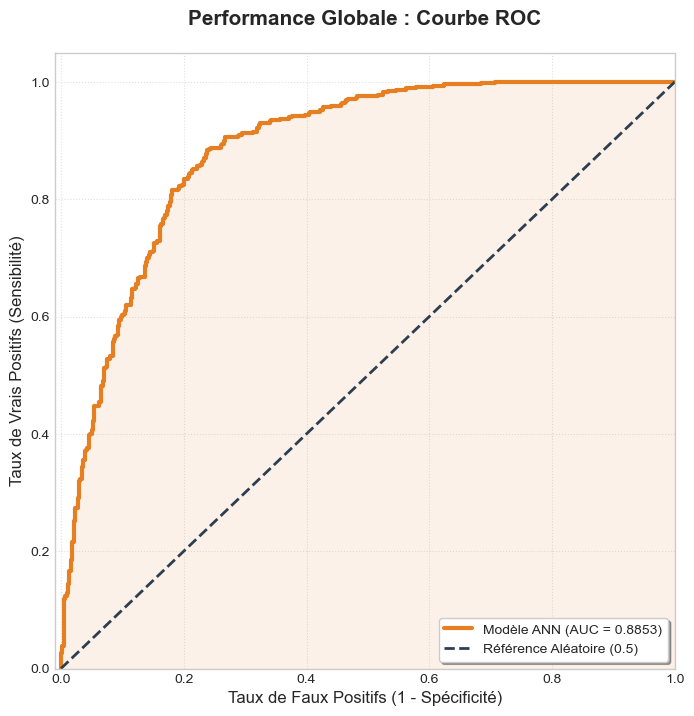

In [12]:
# D. Courbe ROC 
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='#e67e22', lw=3, label=f'Modèle ANN (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#2c3e50', lw=2, linestyle='--', label='Référence Aléatoire (0.5)')

# Mise en forme 
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (Sensibilité)', fontsize=12)
plt.title("Performance Globale : Courbe ROC", fontweight='bold', fontsize=15, pad=20)
plt.legend(loc="lower right", frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

# Ajout d'une ombre sous la courbe pour le style
plt.fill_between(fpr, tpr, alpha=0.1, color='#e67e22')

plt.savefig(f'{dossier_export}/04_Courbe_ROC_ANN.png', dpi=300, bbox_inches='tight')
plt.show() # Pour vérifier le résultat immédiatement